# Лабораторная работа №8
### Реализация схемы цифровой подписи на основе RSA


**Теоретическая часть:**
- Цифровая подпись RSA: создаётся путём вычисления подписи от хеша сообщения с приватным ключом (например, с использованием схемы PKCS#1 v1.5 или RSA-PSS). Проверка — вычисление и сравнение с публичным ключом.
- **PKCS#1 v1.5** — старая, широко используемая схема; <br>
**PSS** (Probabilistic Signature Scheme) — рекомендованная современная схема с солью и лучшими формальными свойствами.
- **Detached signature** — тип подписи, при котором подпись хранится в отдельном файле, а не встраивается внутрь подписываемого документа(удобно для больших файлов / артефактов).


### Задание 1. Реализация RSA-подписи (PKCS#1 и PSS)

1. Сгенерировать ключи RSA (2048 бит).  
2. Подписать короткое сообщение двумя способами: PKCS#1 v1.5 и PSS (SHA-256).  
3. Проверить подписи для оригинального сообщения и для подложенного (tampered) сообщения.
4. Показать, что изменение сообщения ломает проверку.


In [2]:
pip install pycryptodome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 19.9 MB/s eta 0:00:00


In [ ]:
# Требуется: pip install pycryptodome

from Crypto.PublicKey import RSA
from Crypto.Signature import pkcs1_15, pss
from Crypto.Hash import SHA256
import binascii

# your code here
# 1) Генерация ключей (2048 бит)

message = b"Important message for L8 - RSA signature//test"

# 2) PKCS#1 v1.5 подпись


# 3) PSS подпись


# print('PKCS#1 v1.5 signature (hex):', )
# print('PSS signature (hex):', )

# 4) Проверка (на корректность)

# 5) Проверка (подмена сообщения)
tampered = b"Tampered message"

# Образец итогового вывода
# PKCS#1 v1.5 signature (hex):  ...
# PSS signature (hex):  ...
# PKCS#1 v1.5: verification OK
# PSS: verification OK
# PKCS#1 v1.5 (tampered): verification FAILED (expected)
# PSS (tampered): verification FAILED (expected)

**Вопросы:**

> 1. **Почему PSS считается безопаснее, чем PKCS#1 v1.5?**  

> 2. **Можно ли подписью подтвердить целостность только части сообщения?**  

> 3. **Почему мы используем SHA-256, а не что-то слабее?**  


### Задание 2. Detached-подпись файла и простая имитация timestamp

1. Сгенерировать файл `sample.bin`.  
2. Произвести detached-подпись файла (подпись хранится отдельно).  
3. Создать `signature_wrapper.json` с полями: `signature_hex`, `timestamp`, `timestamp_sig_hex`.  
4. Реализовать проверки: подпись файла и подпись timestamp wrapper.
5. Предоставить/продемонстрировать:

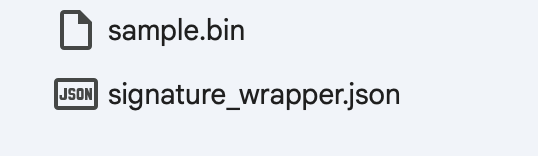

**Detached-подпись** — это подпись, которая хранится отдельно от документа/файла. При такой схеме сам файл не меняется: проверяющий получает файл и отдельный файл-подпись. <br>

Преимущества:
- можно проверять большие артефакты без их изменения;
- удобно для CI/CD и хранилищ артефактов;
- подпись остаётся стабильной при переносе/копировании файла.

Для долгосрочной валидации обычно добавляют время подписи (timestamp), заверенное подписью доверенной Time Stamping Authority (TSA).



In [ ]:
from Crypto.PublicKey import RSA
from Crypto.Signature import pss
from Crypto.Hash import SHA256
import binascii, json
from datetime import datetime, timezone

# your code here
# генерация ключей

# создание sample.bin

# подпись файла (detached)
# print("Detached signature (hex):", )

# timestamp wrapper (timezone-aware UTC)

# подпись payload (timestamping signature)

# проверки

# Detached signature (hex):  ...
# File signature valid: True
# Timestamp signature valid

**Вопросы:**

> 1. **Почему detached-подпись удобна для supply-chain?**  

> 2. **Как таймстамп помогает в long-term validation?**  


### Задание 3. Поиск и исправление уязвимостей в коде подписи


Ниже представлен код, который содержит уязвимости в реализации подписи. Необходимо:
1. Запустить код и найти уязвимости.
2. Описать найденные уязвимости.
3. Исправить код.  
4. Предоставить исправленный код и краткий отчёт «уязвимость → исправление → почему это безопасно».  


In [3]:
from Crypto.PublicKey import RSA
from Crypto.Hash import MD5
from Crypto import Random
import binascii

key_vuln = RSA.generate(1024)
n = key_vuln.n
e = key_vuln.e
d = key_vuln.d

def unsafe_sign(message_bytes):
    h = MD5.new(message_bytes)
    m_int = int.from_bytes(h.digest(), byteorder='big')
    sig_int = pow(m_int, d, n)
    sig = sig_int.to_bytes((sig_int.bit_length()+7)//8, byteorder='big')
    return sig

def unsafe_verify(message_bytes, sig):
    sig_int = int.from_bytes(sig, byteorder='big')
    m_rec = pow(sig_int, e, n)
    m_bytes = m_rec.to_bytes((m_rec.bit_length()+7)//8, byteorder='big')
    h = MD5.new(message_bytes)
    return m_bytes.endswith(h.digest())

msg = b"Transfer 1000 to Bob"
sig = unsafe_sign(msg)
print('signature (hex):', binascii.hexlify(sig).decode())
print('verify (unsafe):', unsafe_verify(msg, sig))


signature (hex): 837c40112c68c828256c5a95d9e9d9273e8d751120eab7087155d7792a4af8e3ac2df396225a64f8a4c7d456e8f969505c2b55294b155d4759d2ac949983fe518944a7315418b2be858bf0b001ba0118341f121fbfecc35e80d214411029546eb0b7ab81e6e61a800e852aa44b6b35659b7be28f346b301240e9f4aa2cb5b36a
verify (unsafe): True


In [ ]:
# Задание 3 — исправленная версия
from Crypto.PublicKey import RSA
from Crypto.Signature import pss
from Crypto.Hash import SHA256
import binascii

# your code here


**Вопросы:**

> 1. **Почему MD5 нельзя использовать для подписи?**  

> 2. **Почему нельзя использовать "сырую" операцию pow(hash, d, n) без паддинга?**  

> 3. **Почему важно использовать ключи >=2048 бит и защищённые схемы подписи?**  
